## Installing all libraries

In [2]:
!pip install torch torchvision pycocotools matplotlib scikit-learn tqdm

## Import Libraries

In [3]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from tqdm import tqdm
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import VOCDetection

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [5]:
# Configuration ( According to research paper )
data_root = "./data"
num_classes = 20
embed_dim = 64
lstm_hidden = 512
dropout = 0.5
weight_decay = 1e-4
momentum = 0.9
lr = 1e-4
batch_size = 32
num_epochs = 50
beam_size = 2
k_eval = 3
seed = 42

In [6]:
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

## Dataset

In [7]:
VOC_CLASSES = [
"aeroplane","bicycle","bird","boat","bottle","bus","car","cat","chair","cow",
"diningtable","dog","horse","motorbike","person","pottedplant","sheep","sofa","train","tvmonitor"
]

# Frequency ordering ( predict common labels first)
VOC_FREQ_ORDER = [14,6,4,1,8,11,18,2,13,16,7,19,12,9,3,15,5,0,17,10]

In [8]:
class VOC2007Dataset(Dataset):

    def __init__(self, root, split, transform):
        self.transform = transform
        self.classes = VOC_CLASSES
        self.freq_order = VOC_FREQ_ORDER
        self.voc = VOCDetection(root=root, year="2007", image_set=split, download=True)

    def __len__(self): return len(self.voc)

    # getting ground truth multi hot vector + making labels ordered
    def __getitem__(self, idx):
        img, target = self.voc[idx]
        img = img.convert("RGB")

        # Multi-label vector (C-dimensional binary vector)
        label_vec = torch.zeros(num_classes)

        objs = target["annotation"].get("object", [])
        if isinstance(objs, dict): objs=[objs]

        for obj in objs:
            if obj["name"] in self.classes:
                label_vec[self.classes.index(obj["name"])] = 1

        # Ordered labels (sequence modeling idea)
        present = set(torch.where(label_vec==1)[0].tolist())
        ordered = [c for c in self.freq_order if c in present]

        return self.transform(img), label_vec, ordered

In [9]:
def transform(train):
    mean=[0.485,0.456,0.406]; std=[0.229,0.224,0.225]

    if train:
        return transforms.Compose([
            transforms.Resize((224,224)),
            transforms.RandomHorizontalFlip(), # data augumentation
            transforms.ColorJitter(0.2,0.2,0.2), # data augumentation
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ])
    return transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(mean,std)
    ])


def collate_fn(batch):
    return torch.stack([b[0] for b in batch]), \
           torch.stack([b[1] for b in batch]), \
           [b[2] for b in batch]

train_ds = VOC2007Dataset(data_root,"trainval",transform(True))
test_ds  = VOC2007Dataset(data_root,"test",transform(False))

train_loader = DataLoader(train_ds,batch_size,True,collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,batch_size,False,collate_fn=collate_fn)

100%|██████████| 460M/460M [00:19<00:00, 24.2MB/s]
100%|██████████| 451M/451M [00:18<00:00, 25.0MB/s]


## Model

In [10]:
class CNNRNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.C = num_classes
        self.START = num_classes
        self.END = num_classes+1

        # Label embedding matrix W ∈ R^(C+2 × d)
        self.label_embed = nn.Embedding(num_classes+2, embed_dim)

        # CNN backbone (VGG16)
        vgg = models.vgg16(pretrained=True)
        self.cnn_features = vgg.features
        self.cnn_avgpool = vgg.avgpool

        self.cnn_fc = nn.Sequential(*list(vgg.classifier.children())[:-2])
        self.img_dim = 4096

        # Freezing BOTH the conv layers and the fully connected layers
        for p in self.cnn_features.parameters():
            p.requires_grad = False
        for p in self.cnn_fc.parameters():
            p.requires_grad = False

        # RNN (sequence modeling)
        self.lstm = nn.LSTM(embed_dim,lstm_hidden,batch_first=True)

        # Projection layers
        self.proj_rnn = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, embed_dim)
        ) # label embedding projection

        self.proj_img = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(4096, embed_dim)
        ) # image embedding projection

    def extract_img(self,x):
        with torch.no_grad():
            f=self.cnn_features(x)
        f=self.cnn_avgpool(f)
        return self.cnn_fc(f.flatten(1))

    def get_W(self):

        # Preventing START token from prediction
        W=self.label_embed.weight.clone()
        W[self.START]=-1e9
        return W

    def forward(self,images,seq):
        """
        x = ReLU(W_rnn*h_t + W_img*f_img)
        Scores:
        s = x @ W^T
        """
        img=self.proj_img(self.extract_img(images))
        lbl=self.label_embed(seq)

        out,_=self.lstm(lbl)
        rnn=self.proj_rnn(out)

        x=torch.relu(rnn+img.unsqueeze(1))
        return x @ self.get_W().t()


    @torch.no_grad()
    def predict_beam(self, images, beam_size=2):
        B = images.size(0)
        device = images.device

        img_feat = self.extract_img(images)
        img_emb = self.proj_img(img_feat)

        results = []

        for b in range(B):
            ie = img_emb[b:b+1]

            # START
            tok = torch.tensor([[self.START]], device=device)
            emb = self.label_embed(tok)

            out, hidden = self.lstm(emb)
            rnn = self.proj_rnn(out.squeeze(1))

            x = torch.relu(rnn + ie)
            scores = x @ self.get_W().t()

            log_probs = torch.log_softmax(scores, dim=-1)[0]
            top_lp, top_idx = log_probs.topk(beam_size)

            # S(t): intermediate paths (score, sequence, hidden_state)
            intermediate_paths = [(top_lp[i].item(), [top_idx[i].item()], hidden) for i in range(beam_size)]
            candidate_paths = []

            while intermediate_paths:
                new_beams = []

                for score, seq, hid in intermediate_paths:
                    # If the path naturally predicted END, move it to candidates
                    if seq[-1] == self.END:
                        candidate_paths.append((score, seq))
                        continue

                    # preventing infinite loops
                    if len(seq) > self.C:
                        candidate_paths.append((score, seq))
                        continue

                    last = torch.tensor([[seq[-1]]], device=device)
                    emb = self.label_embed(last)

                    out, new_hid = self.lstm(emb, hid)
                    rnn = self.proj_rnn(out.squeeze(1))

                    x = torch.relu(rnn + ie)
                    scores = x @ self.get_W().t()

                    log_probs = torch.log_softmax(scores, dim=-1)[0]
                    top_lp, top_idx = log_probs.topk(beam_size)

                    for i in range(beam_size):
                        lbl = top_idx[i].item()

                        # Avoiding duplicates in the same sequence
                        if lbl not in seq:
                            new_beams.append((
                                score + top_lp[i].item(),
                                seq + [lbl],
                                new_hid
                            ))

                if not new_beams:
                    break

                new_beams.sort(key=lambda x: x[0], reverse=True)
                intermediate_paths = new_beams[:beam_size]

                #stopping if current intermediate paths are worse than all candidate paths
                if candidate_paths:
                    min_candidate_prob = min([p[0] for p in candidate_paths])
                    if intermediate_paths[0][0] < min_candidate_prob:
                        break

            candidate_paths.extend([(p[0], p[1]) for p in intermediate_paths if p[1][-1] != self.END])
            candidate_paths.sort(key=lambda x: x[0], reverse=True)

            best_seq = candidate_paths[0][1] if candidate_paths else []

            # removing END token from final output
            clean_seq = [l for l in best_seq if l < self.C]

            results.append(clean_seq)

        return results

In [11]:
#Model
model = CNNRNN().to(DEVICE)

optimizer = optim.RMSprop(
    [p for p in model.parameters() if p.requires_grad],
    lr=lr,
    weight_decay=weight_decay,#1e-4
    momentum=momentum#0.9
)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 181MB/s]


## Training

In [12]:
# Preparing sequences for beam search
def prepare_seq(ordered):

    B=len(ordered)
    START=num_classes; END=num_classes+1

    seqs=[o+[END] if o else [END] for o in ordered]
    T=max(len(s) for s in seqs)+1

    inp=torch.zeros(B,T,dtype=torch.long,device=DEVICE)
    tgt=torch.full((B,T-1),-100,dtype=torch.long,device=DEVICE)
    mask=torch.zeros(B,T-1,device=DEVICE)

    for b,s in enumerate(seqs):
        inp[b,0]=START
        inp[b,1:len(s)+1]=torch.tensor(s,device=DEVICE)
        tgt[b,:len(s)]=torch.tensor(s,device=DEVICE)
        mask[b,:len(s)]=1

    return inp,tgt,mask

In [13]:
def train_epoch(model,loader,opt):
    model.train()
    crit=nn.CrossEntropyLoss(reduction="none",ignore_index=-100)
    nn.utils.clip_grad_norm_(model.parameters(), 5.0)

    total=0
    for imgs,_,ordered in tqdm(loader,leave=False):
        imgs=imgs.to(DEVICE)

        inp,tgt,mask=prepare_seq(ordered)

        scores=model(imgs,inp[:,:-1])
        B,T,V=scores.shape

        # Loss:
        # L = - Σ log P(y_t | y_<t, image)
        loss=crit(scores.view(B*T,V),tgt.view(B*T))
        loss=(loss*mask.view(B*T)).sum()/mask.sum()

        opt.zero_grad()
        loss.backward()
        opt.step()

        total+=loss.item()

    return total/len(loader)

In [14]:
# train function
def train(model, train_loader, optimizer):
    losses = []
    for epoch in range(1, num_epochs + 1):
        loss = train_epoch(model, train_loader, optimizer)
        print(f"Epoch {epoch} | Loss: {loss:.4f}")

        losses.append(loss)

    return losses

In [15]:
losses = train(model, train_loader, optimizer) # 157 batches

Epoch 1 | Loss: 1.7754


Epoch 2 | Loss: 1.2501


Epoch 3 | Loss: 1.1151


Epoch 4 | Loss: 1.0207


Epoch 5 | Loss: 0.9536


...

Epoch 46 | Loss: 0.5435


Epoch 47 | Loss: 0.5396


Epoch 48 | Loss: 0.5344


Epoch 49 | Loss: 0.5262


Epoch 50 | Loss: 0.5247


## Evaluation

In [16]:
from sklearn.metrics import average_precision_score

@torch.no_grad()
def evaluate(model, loader):

    model.eval()
    C = model.C

    P, G, S = [], [], []

    for imgs, labels, _ in loader:

        imgs = imgs.to(DEVICE)
        B = imgs.size(0)

        # Getting Probability scores (For mAP)
        W = model.get_W()

        # START Token
        start_tok = torch.full((B,), model.START, dtype=torch.long, device=DEVICE)
        start_emb = model.label_embed(start_tok.unsqueeze(1))

        lst_out, _ = model.lstm(start_emb)
        rnn = model.proj_rnn(lst_out.squeeze(1)) # rnn projection

        img = model.proj_img(model.extract_img(imgs)) #img projection

        x = torch.relu(rnn + img)

        raw_scores = x @ W.t()
        probs = torch.softmax(raw_scores,dim=-1)[:,:C].cpu().numpy() # probabilities

        # Getting Label Predictions (Beam Search)
        preds = model.predict_beam(imgs)

        for b in range(B):

            # Binary prediction vector (top-k)
            vec = np.zeros(C)
            for l in preds[b][:k_eval]:
                if l < C:
                    vec[l] = 1

            P.append(vec)
            G.append(labels[b].numpy())
            S.append(probs[b])

    P = np.array(P)
    G = np.array(G)
    S = np.array(S)

    # METRICS
    # Overall Precision , Recall , F1-Scores
    tp = (P * G).sum()
    OP = tp / (P.sum() + 1e-8)
    OR = tp / (G.sum() + 1e-8)
    OF1 = 2 * OP * OR / (OP + OR + 1e-8)

    # Class-wise Precision , Recall , F1-Scores
    cp, cr = [], []
    for c in range(C):
        if G[:, c].sum() == 0:
            continue

        tp_c = (P[:, c] * G[:, c]).sum()

        cp.append(tp_c / (P[:, c].sum() + 1e-8))
        cr.append(tp_c / (G[:, c].sum() + 1e-8))

    CP = np.mean(cp)
    CR = np.mean(cr)
    CF1 = 2 * CP * CR / (CP + CR + 1e-8)

    # mAP
    ap = []
    for c in range(C):
        if G[:, c].sum() > 0:
            ap.append(average_precision_score(G[:, c], S[:, c]))

    mAP = np.mean(ap) if ap else 0.0

    return dict(CP=CP, CR=CR, CF1=CF1, OP=OP, OR=OR, OF1=OF1, mAP=mAP), P, G, S

In [20]:
# Final Evaluation + Visualizations
def evaluate_model(model, test_loader, losses):

    save_dir = "results"
    os.makedirs(save_dir, exist_ok=True)

    # Evaluation
    metrics, P, G, S = evaluate(model, test_loader)

    metrics_df = pd.DataFrame([metrics]).round(4)

    print("\nFinal Metrics:")
    display(metrics_df)

    metrics_df.to_csv(f"{save_dir}/metrics.csv", index=False)

    # Training curve
    plt.figure(figsize=(6,4))
    plt.plot(losses, label="Loss", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/training_curve.png", dpi=150)
    plt.show()
    plt.close()

    # Per-class AP
    ap_values = [
        average_precision_score(G[:, i], S[:, i]) if G[:, i].sum() > 0 else 0
        for i in range(len(VOC_CLASSES))
    ]

    df = pd.DataFrame({
        "Class": VOC_CLASSES,
        "AP": ap_values
    }).round(4)

    print("\nPer-class AP Table:")
    display(df)

    df.to_csv(f"{save_dir}/per_class_ap.csv", index=False)

    # Bar Plot
    plt.figure(figsize=(12,5))
    plt.bar(df["Class"], df["AP"])
    plt.xticks(rotation=45, ha="right")
    plt.title("Per-Class Average Precision")
    plt.ylabel("AP")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/per_class_ap.png", dpi=150)
    plt.show()
    plt.close()

    # Sorted results
    df_sorted = df.sort_values(by="AP", ascending=False)
    df_sorted.to_csv(f"{save_dir}/per_class_ap_sorted.csv", index=False)

    plt.figure(figsize=(12,5))
    plt.bar(df_sorted["Class"], df_sorted["AP"])
    plt.xticks(rotation=45, ha="right")
    plt.title("Per-Class AP (Sorted)")
    plt.ylabel("AP")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/per_class_ap_sorted.png", dpi=150)
    plt.show()
    plt.close()

    print(f"\n Results saved in '{save_dir}/'")

    return metrics_df, df


Final Metrics:


,CP,CR,CF1,OP,OR,OF1,mAP
0,0.7685,0.7191,0.743,0.8001,0.7351,0.7662,0.6523


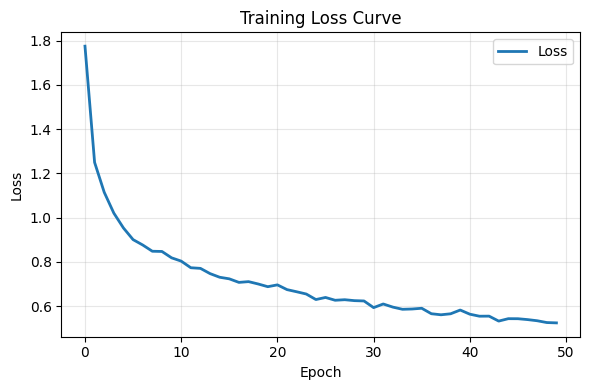


Per-class AP Table:


,Class,AP
0,aeroplane,0.9414
1,bicycle,0.3762
2,bird,0.8948
3,boat,0.8430
4,bottle,0.3183
5,bus,0.6407
6,car,0.8181
7,cat,0.9011
8,chair,0.5442
9,cow,0.7384


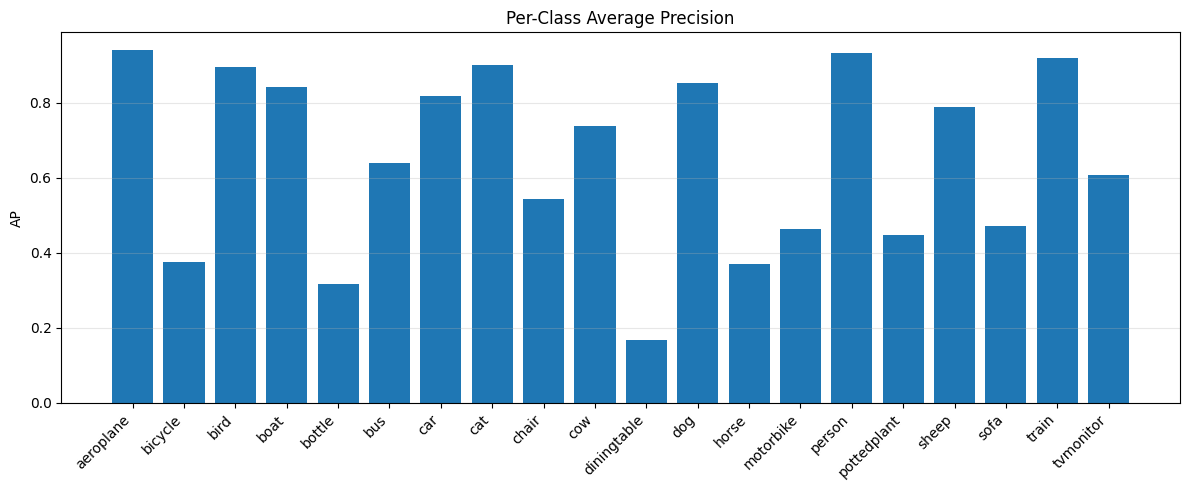

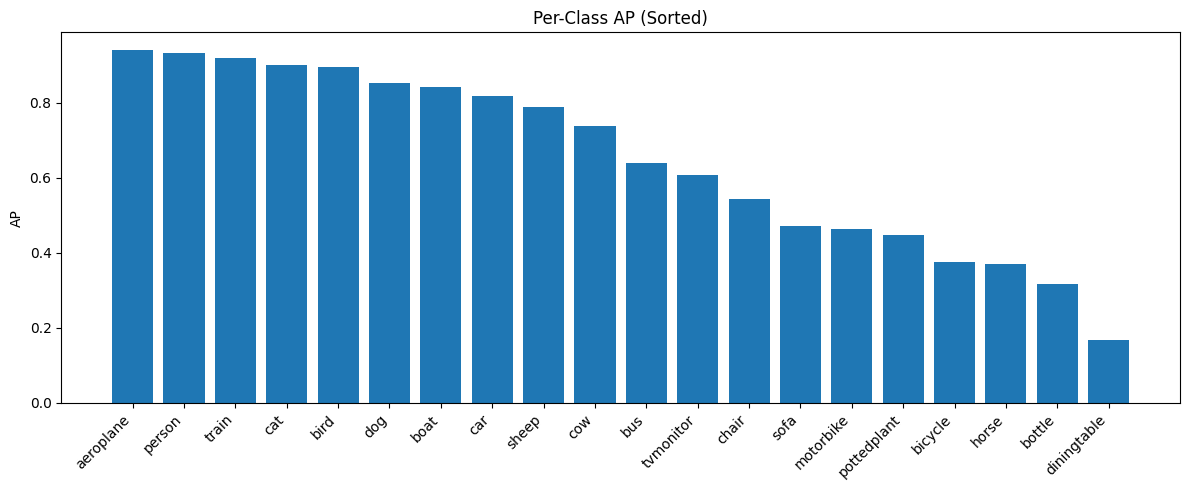


 Results saved in 'results/'


In [21]:
metrics, df = evaluate_model(model, test_loader, losses)

In [19]:
torch.save(model.state_dict(), "finalmodel.pth")

In [27]:
#Data from the Research Paper
paper_results = {
    "Class": ["plane", "bike", "bird", "boat", "bottle", "bus", "car", "cat", "chair", "cow",
              "table", "dog", "horse", "motor", "person", "plant", "sheep", "sofa", "train", "tv", "mAP"],
    "CNN-RNN (Research Paper)": [96.7, 83.1, 94.2, 92.8, 61.2, 82.1, 89.1, 94.2, 64.2, 83.6,
                                 70.0, 92.4, 91.7, 84.2, 93.7, 59.8, 93.2, 75.3, 99.7, 78.6, 84.0]
}

# Data from Implementation
# Scaled to 0-100 for comparison
impl_results = {
    "CNN-RNN (Implementation)": [95.3, 42.0, 89.8, 80.1, 35.4, 66.5, 81.8, 89.4, 55.3, 73.8,
                                 15.4, 85.7, 31.2, 50.8, 92.6, 46.9, 78.7, 38.3, 92.0, 60.5, 65.07]
}

df_compare = pd.DataFrame(paper_results)
df_compare["CNN-RNN (Implementation)"] = impl_results["CNN-RNN (Implementation)"]

# Display the Clean Table
print("\nPerformance comparison : Research paper vs Implementation")
display(df_compare.style.format(precision=2))
df_compare.to_csv("results/paper_vs_implementation.csv", index=False)


Performance comparison : Research paper vs Implementation


,Class,CNN-RNN (Research Paper),CNN-RNN (Implementation)
0,plane,96.70,95.30
1,bike,83.10,42.00
2,bird,94.20,89.80
3,boat,92.80,80.10
4,bottle,61.20,35.40
5,bus,82.10,66.50
6,car,89.10,81.80
7,cat,94.20,89.40
8,chair,64.20,55.30
9,cow,83.60,73.80


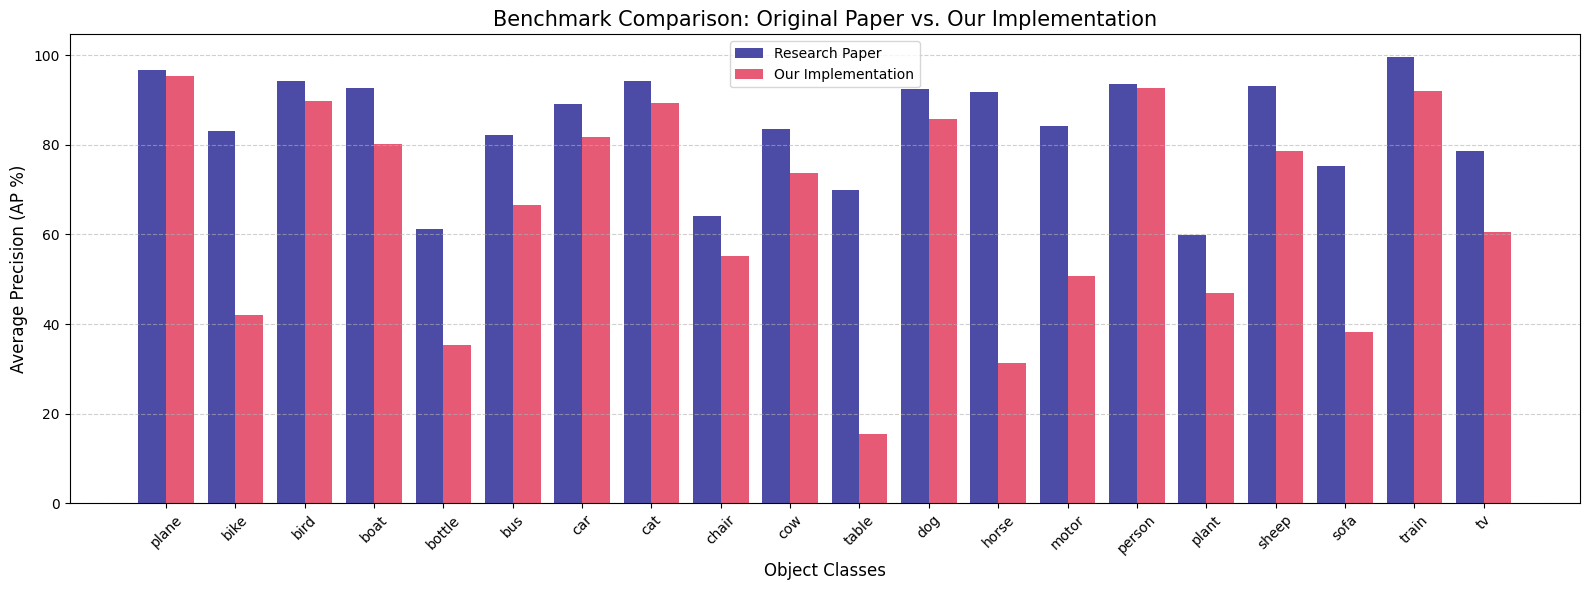

<Figure size 640x480 with 0 Axes>

In [26]:
# Grouped Bar Chart for easier visual comparison
df_plot = df_compare[df_compare["Class"] != "mAP"]
classes = df_plot["Class"]
x = range(len(classes))

plt.figure(figsize=(16, 6))
plt.bar(x, df_plot["CNN-RNN (Research Paper)"], width=0.4, label='Research Paper', color='navy', alpha=0.7)
plt.bar([i + 0.4 for i in x], df_plot["CNN-RNN (Implementation)"], width=0.4, label='Our Implementation', color='crimson', alpha=0.7)

plt.xlabel('Object Classes', fontsize=12)
plt.ylabel('Average Precision (AP %)', fontsize=12)
plt.title('Benchmark Comparison: Original Paper vs. Our Implementation', fontsize=15)
plt.xticks([i + 0.2 for i in x], classes, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

plt.savefig("results/comparison_benchmark.png", dpi=150)